In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
## general libraries
import pathlib
from rich.pretty import install, pprint

## data handling libraries
import numpy as np
import pandas as pd
import xarray as xr
from tqdm.dask import TqdmCallback as ProgressBarDask

# plotting libraries
import matplotlib.pyplot as plt

## machine learning libraries
import gpytorch 
import torch

## PAMIR libraries
import plots
import mlflow
import hydra
import yaml
import pamir_mlpermafrost as pamir
from cryogrid_pytools import xr_raster_vector

install(overflow=True)

In [114]:
uri = "file:///home/jovyan/work/pamir-MLpermafrost/mlruns"

In [137]:
def get_run_data(run):
    artifacts = pathlib.Path(run.info.artifact_uri.replace('file://', ''))
    fnames = list(artifacts.glob('**/*.nc'))
    if not fnames:
        return
    data = xr.open_mfdataset(fnames, preprocess=assign_season_depth_to_data)

    seed = int(run.data.params['seed'])
    data = data.expand_dims(seed=[seed])
    data.attrs = {}

    return data

def extract_seas_depth_from_var_name(var_name):
    """
    Extracts the season and depth from the variable name.
    
    Args:
        var_name (str): The variable name containing season and depth information.
        
    Returns:
        tuple: A tuple containing the season (str) and depth (float).
    """
    import re
    pattern = re.compile(r'([JFMAMSOND]{3})_([\d\.]{1,4})')
    season, depth = pattern.findall(var_name)[0]
    newname = var_name.replace(f"{season}_{depth}", "")
    depth = float("0." + depth[1:]) if depth.startswith('0') else float(depth)
    return season, depth, newname

def assign_season_depth_to_data(data):
    """
    Assigns season and depth attributes to the data based on variable names.
    
    Args:
        data (xarray.Dataset): The dataset containing variables with season and depth information.
        
    Returns:
        xarray.Dataset: The dataset with season and depth attributes assigned.
    """
    for key in data.data_vars:
        season, depth, newname = extract_seas_depth_from_var_name(key)
        data = data.expand_dims(season=[season], depth=[depth])
        data[key].attrs = {}
        data = data.rename({key: newname})
    return data

In [138]:
client = mlflow.client.MlflowClient(uri)
exp = client.get_experiment_by_name("horzband_split")

# get mlflow runs for experiment
runs = client.search_runs(experiment_ids=exp.experiment_id)

In [140]:
ds_list = [get_run_data(r) for r in runs]
ds_list = [d for d in ds_list if d is not None]
ds = xr.combine_by_coords(ds_list)

/home/jovyan/work/pamir-MLpermafrost/.venv/lib/python3.12/site-packages/dask/array/core.py:5003: PerformanceWarning: Increasing number of chunks by factor of 32
  result = blockwise(
/home/jovyan/work/pamir-MLpermafrost/.venv/lib/python3.12/site-packages/dask/array/core.py:5003: PerformanceWarning: Increasing number of chunks by factor of 32
  result = blockwise(


In [144]:
with ProgressBarDask():
    da = ds.yhat_avg_ground_temp.std('seed').sel(season='JAS', depth=5).compute()

  0%|          | 0/8193 [00:00<?, ?it/s]

In [147]:
with ProgressBarDask():
    da_std = ds.yhat_std_ground_temp.mean('seed').sel(season='JAS', depth=5).compute()

  0%|          | 0/8193 [00:00<?, ?it/s]

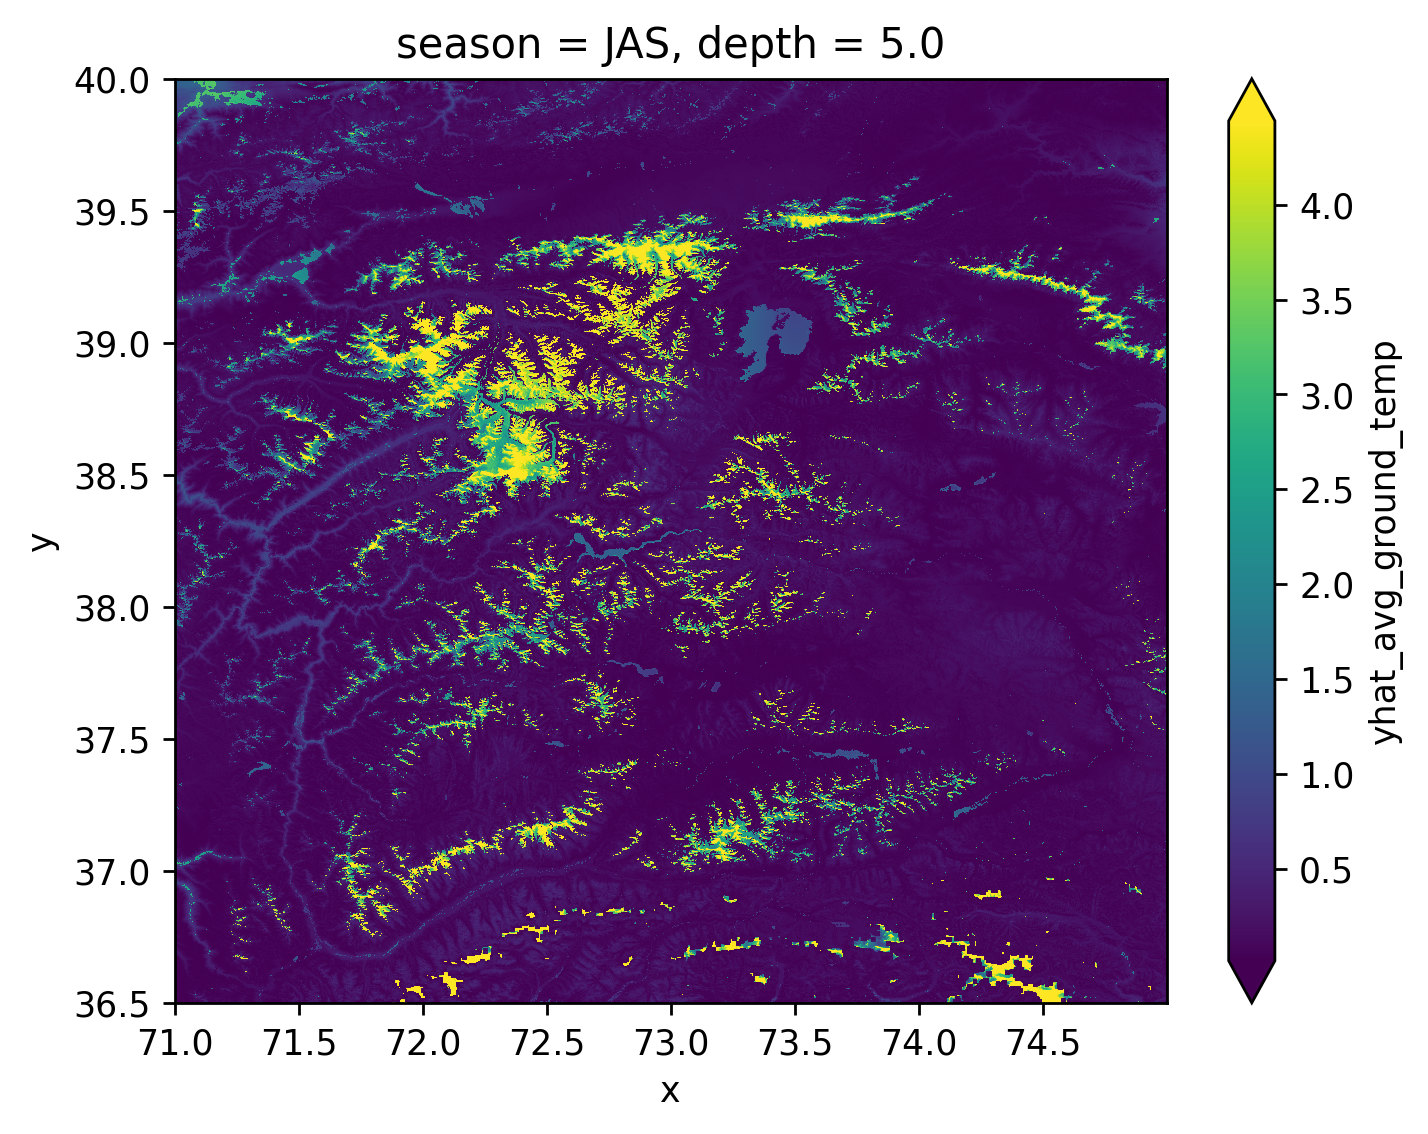

In [146]:
img = da.plot.imshow(robust=True, center=False)
img.figure.set_dpi(250)

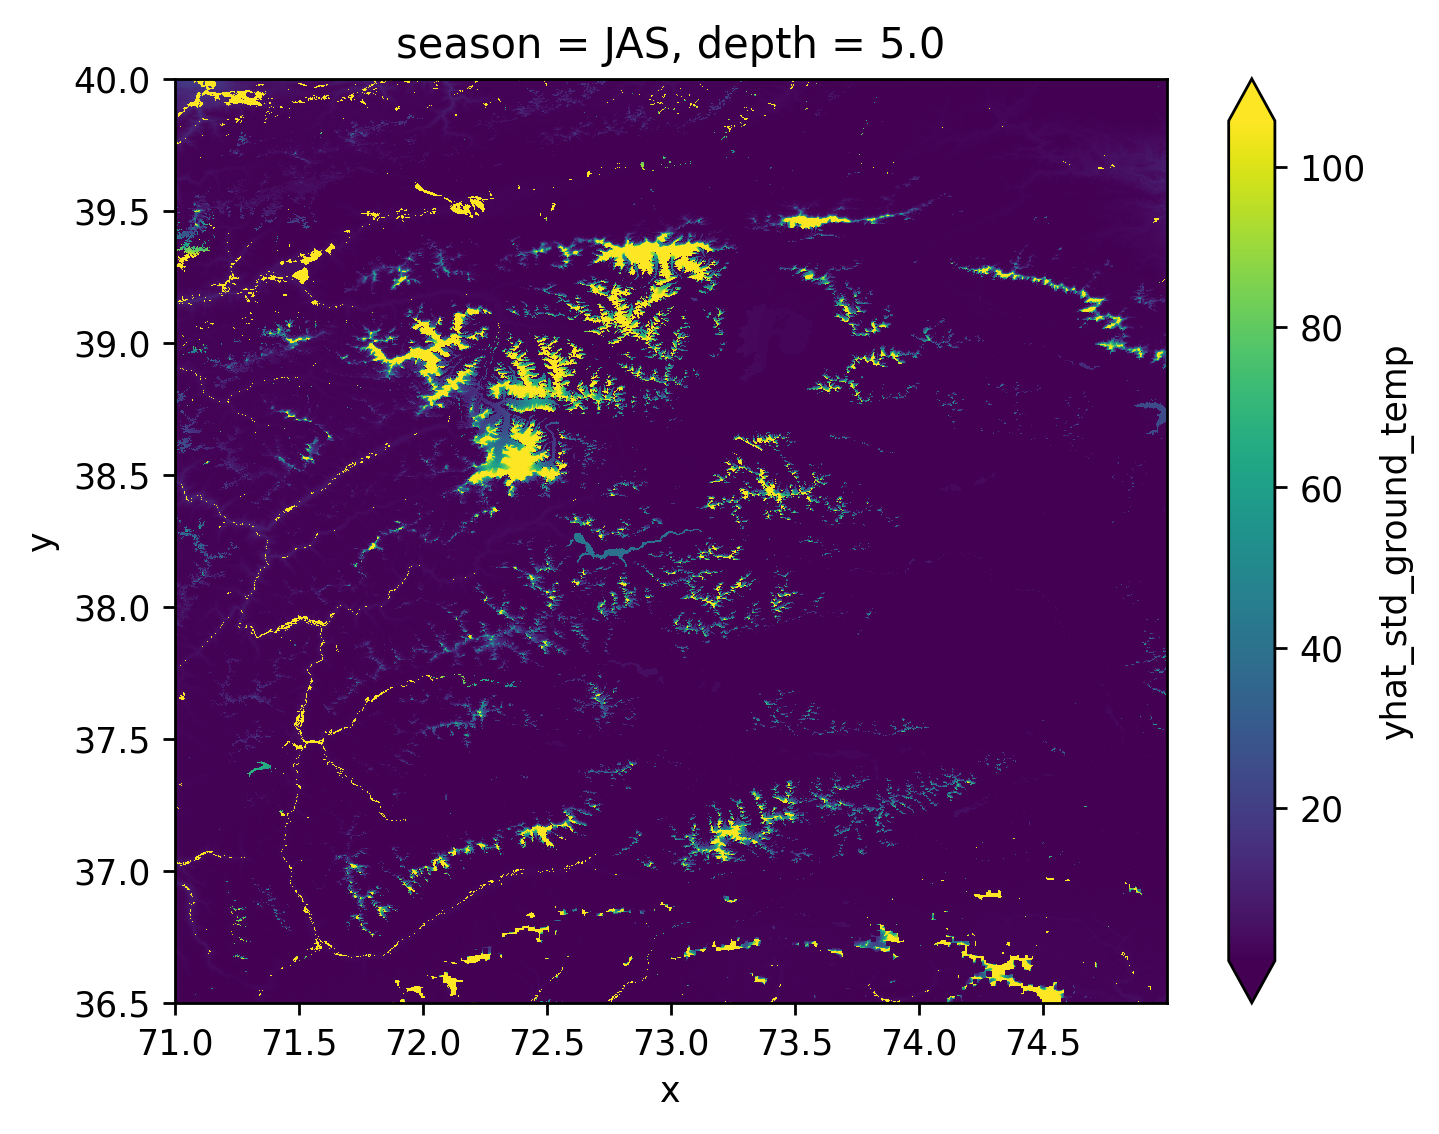

In [148]:
img = da_std.plot.imshow(robust=True, center=False)
img.figure.set_dpi(250)